# Option Pricing Monte Carlo Simulation

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import yfinance as yf

### **1) Calculate daily risk-free rate & daily standard deviation**
> Calculate the daily risk-free return (assuming 252 trading day is fine for this exercise) and daily standard deviation of QQQ. You can use the past 90 trading history to calculate the QQQ volatility.

In [ ]:
# use below link to get number of workdays from apr 7 to sep 30, 2025
# https://www.timeanddate.com/date/workdays.html?d1=07&m1=04&y1=2025&d2=30&m2=09&y2=2025&ti=on&
num_days = 121

# given risk-free rate, calculate daily risk-free-rate
r = 0.0433
r_daily = r / 252

print('\nDaily risk-free rate:', round(r_daily*100, 4), '%')


Daily risk-free rate: 0.0172 %


In [ ]:
symbol = 'QQQ'

# get stock data from yahoo finance api
stock_data = yf.download(symbol)['Close']

# subset to past 90 days assuming today is Apr 7, 2025
stock_data = stock_data[stock_data.index<='2025-04-07']
stock_data = stock_data.tail(90)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
# calculate daily returns
stock_data['Returns'] = stock_data.pct_change()

# calculate daily return standard deviation
sigma = stock_data['Returns'].std()

print('\nDaily stock return standard deviation:', round(sigma*100, 4), '%')


Daily stock return standard deviation: 1.5729 %


### **2) Simulate 100,000 paths**
> Simulate 100,000 paths of QQQ price that ends on September 30, 2025. (Refer back to the lecture slide to see this step)

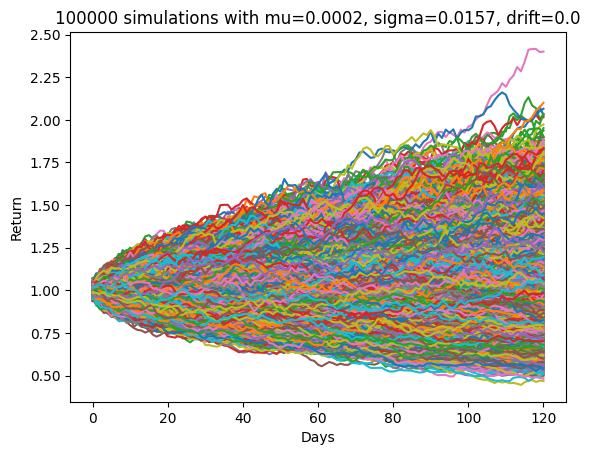

In [ ]:
# set simulation parameter
num_of_sim = 100000

# calclulate drift using expected return (mu) = risk free rate (risk-neutral pricing)
drift = r_daily - (sigma**2)/2

# calculate simulated returns (geometric brownian motion)
Z = stats.norm.ppf(np.random.rand(num_days, num_of_sim))
daily_returns = np.exp(drift + sigma * Z)
gbm_rtn = np.cumprod(daily_returns, axis=0)

# plot cumulative returns
plt.plot(gbm_rtn)
plt.title(f'{num_of_sim} simulations with mu={round(r_daily,4)}, sigma={round(sigma,4)}, drift={round(drift,4)}')
plt.xlabel('Days')
plt.ylabel('Return')
plt.show()

### **3) Calculate simulated expected call option payout**
> For each path, calculate the expected payout of the call option using the function max(simulated stock price – strike price, 0).

In [ ]:
# these prices are given
strike_price = 450
stock_price = 423.69  # as of Apr 7, 2025

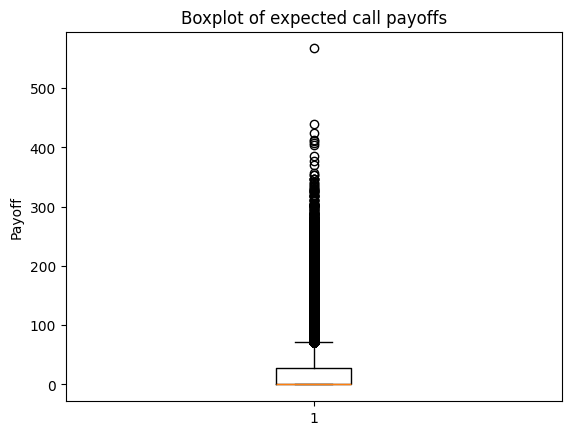

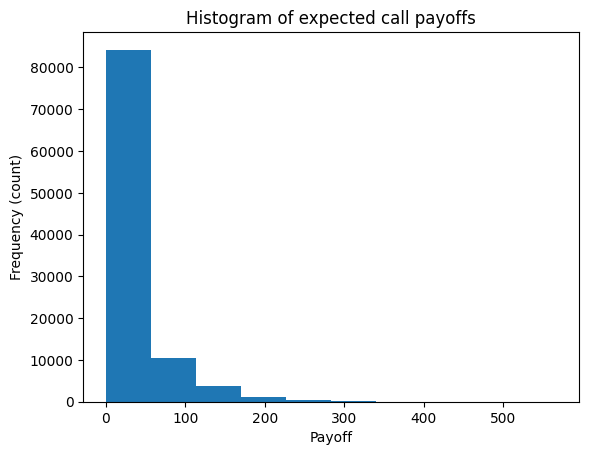

In [ ]:
# calculate simulation's final stock price and expected call payoffs
stock_price_sim = [stock_price * cum_ret for cum_ret in gbm_rtn[-1]]
expected_call_payoff = [max(end_price - strike_price, 0) for end_price in stock_price_sim]

# boxplot of expected call payoffs
plt.boxplot(expected_call_payoff)
plt.title('Boxplot of expected call payoffs')
plt.ylabel('Payoff')
plt.show()

print()

# histogram of expected call payoffs
plt.hist(expected_call_payoff)
plt.title('Histogram of expected call payoffs')
plt.xlabel('Payoff')
plt.ylabel('Frequency (count)')
plt.show()

### **4) Calculate average payout present value**
Calculate the average payout and then discount it back to the evaluation date (the day you are doing the assignment) for the present value. You can use the same risk-free rate as in part (1).

In [ ]:
# calculate present value of avg payout
avg_payout = np.mean(expected_call_payoff)
avg_payout_PV = avg_payout/((1+r_daily)**num_days)

print('\nPresent value of average payout: $', round(avg_payout_PV, 2))


Present value of average payout: $ 21.87


### **5) Price comparison: theoretical calculation vs actual observation**
Compare your calculated price to the last trading price of the option. Are they close?

***Response:***
- The last trading price of the option was \$26.18
- This is somewhat close to the theoretical calculation of \$21.87